# Wikipedia Stability and Contention - EN Data Collection
### IS-618 Social Media Data Analysis - University of Mannheim

---

## Overview

**Target:**
- 200 contested articles (50 per topic)
- 400 stable articles (100 per topic)
- 4 topics: politics_history, culture, geography, science

**Pipeline:**
1. Fetch template titles (POV + Neutrality, up to 2000 each)
2. Collect contested articles with date filter 2022-2025
3. Fetch Good Article titles (43K+, shuffled)
4. Collect stable articles verified no dispute history
5. Match pairs (nearest-neighbour on age, word count, topic)
6. Extract features
7. Statistical analysis

---

## For BW UniCluster

```bash
# Install dependencies
pip install requests pytrends lexicalrichness scikit-learn --user
pip install pandas numpy matplotlib seaborn --user

# Convert and run in background
jupyter nbconvert --to script Wikipedia_Final_EN.ipynb --output final_collect
nohup python final_collect.py > final_log.txt 2>&1 &
echo "Running - PID: $!"

# Check progress anytime
tail -50 final_log.txt
python3 -c "
import json
from collections import Counter
c = json.load(open('final_contested_en.json'))
s = json.load(open('final_stable_en.json'))
print(f'Contested: {len(c)}/200')
print(Counter(a[\"topic\"] for a in c))
print(f'Stable pool: {len(s)}/400')
print(Counter(a[\"topic\"] for a in s))
"
```


## 0. Setup

In [27]:
import requests, time, json, re, random, os, datetime
from datetime import timezone
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.neighbors import NearestNeighbors
from scipy.stats import wilcoxon, mannwhitneyu, norm

try:
    from pytrends.request import TrendReq
    TRENDS_AVAILABLE = True
    print("pytrends loaded")
except:
    TRENDS_AVAILABLE = False
    print("pytrends not available - trends matching skipped")

HEADERS = {"User-Agent": "UniMannheim-SMDA-Final/1.0 (student research uni-mannheim.de)"}
random.seed(42)
print("Setup complete")


pytrends loaded
Setup complete


## 1. Configuration

In [28]:
# Output files - clean names for final production run
CONTESTED_FILE = "final_contested_en.json"
STABLE_FILE    = "final_stable_en.json"
PAIRS_FILE     = "final_pairs_en.json"
FEATURES_FILE  = "final_features_en.csv"
TRENDS_C_FILE  = "final_trends_contested.json"
TRENDS_S_FILE  = "final_trends_stable.json"
GOOD_TITLES_FILE = "final_good_titles_en.json"

# Targets
TARGET_CONTESTED   = 200
TARGET_STABLE_POOL = 400   # 2x contested for matching headroom

# Quality thresholds - same for both groups
# Ensures comparability: stability reflects genuine consensus
# not just low visibility or stub articles
MIN_WORDS    = 1500
MIN_EDITORS  = 15
MIN_AGE_DAYS = 365
MAX_WORDS_STABLE = 8000 

# Matching constraints (validated in pilots v1-v3)
MAX_MATCH_DISTANCE = 5.0
MAX_AGE_GAP_DAYS   = 730
WORD_COUNT_TOL     = 0.20

# Templates - language-level disputes only
# POV and Neutrality confirmed as only EN templates
# with sufficient 2022-2025 coverage (52% pass rate in pilot)
EN_TEMPLATES = ["Template:POV", "Template:Neutrality"]

# Date filter - 2022 to 2025
# 2026 excluded: too recent, articles may not have
# had enough time to develop genuine editorial conflict
VALID_YEARS = [2022, 2023, 2024, 2025]

# Lift Wing topic mapping
# Confirmed working for EN and DE with same taxonomy
# Reference: https://www.mediawiki.org/wiki/ORES/Articletopic
TOPIC_BROAD = {
    "STEM":                "science",
    "Culture":             "culture",
    "Geography":           "geography",
    "History_and_Society": "politics_history",
}

# Topic quotas - strictly balanced
# 200 contested / 4 topics = 50 each
# 400 stable / 4 topics = 100 each
# Pilot Experiment 4 showed geography dominated at 49%
# causing 0.098 F1 drop - quotas fix this
TOPIC_QUOTAS_CONTESTED = {
    "politics_history": 50,
    "culture":          50,
    "geography":        50,
    "science":          50,
}
TOPIC_QUOTAS_STABLE = {
    "politics_history": 100,
    "culture":          100,
    "geography":        100,
    "science":          100,
}

def quota_reached(articles, topic, quotas):
    current = sum(1 for a in articles if a.get("topic") == topic)
    return current >= quotas.get(topic, 999)

def topic_summary(articles, label=""):
    if label:
        print(f"{label}:")
    counts = Counter(a.get("topic", "unknown") for a in articles)
    total  = max(len(articles), 1)
    for t in ["politics_history","culture","geography","science","other"]:
        c = counts.get(t, 0)
        if c > 0 or t != "other":
            bar = "#" * (c // 2)
            print(f"  {t:<20} {c:>4} ({100*c//total:>2}%)  {bar}")

print("Config loaded")
print(f"  Target contested   : {TARGET_CONTESTED} (50 per topic)")
print(f"  Target stable pool : {TARGET_STABLE_POOL} (100 per topic)")
print(f"  Min words          : {MIN_WORDS}")
print(f"  Min editors        : {MIN_EDITORS}")
print(f"  Date filter        : {VALID_YEARS}")
print(f"  Templates          : {EN_TEMPLATES}")


Config loaded
  Target contested   : 200 (50 per topic)
  Target stable pool : 400 (100 per topic)
  Min words          : 1500
  Min editors        : 15
  Date filter        : [2022, 2023, 2024, 2025]
  Templates          : ['Template:POV', 'Template:Neutrality']


## 2. Helper Functions

In [29]:
def safe_get(url, params, retries=5, base_wait=3):
    """Robust Wikipedia API GET with retry and rate limit handling."""
    for attempt in range(retries):
        try:
            r = requests.get(url, params=params, headers=HEADERS, timeout=20)
            if r.status_code == 429:
                print("    Rate limited - waiting 180s...")
                time.sleep(180)
                continue
            if r.status_code == 200 and r.text.strip():
                return r.json()
            time.sleep(base_wait * (attempt + 1))
        except Exception as e:
            time.sleep(base_wait * (attempt + 1))
    return None


def save_json(data, path):
    """Atomic save using temp file - partial writes never corrupt data."""
    tmp = path + ".tmp"
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)
    os.replace(tmp, path)


def load_json(path, default=None):
    if os.path.exists(path):
        with open(path, encoding="utf-8") as f:
            return json.load(f)
    return default if default is not None else []


def is_recent_dispute(text):
    """Check if POV or Neutrality template was added in 2022-2025."""
    templates = re.findall(
        r'\{\{(?:POV|Neutrality)[^}]*\}\}', text, re.IGNORECASE)
    for t in templates:
        m = re.search(r'date=\w+ (20\d{2})', t)
        if m and int(m.group(1)) in VALID_YEARS:
            return True
    return False


def clean_wikitext(text):
    """Strip Wikipedia markup and return plain readable text."""
    text = re.sub(r'\{\{[^{}]*\}\}', '', text)
    text = re.sub(r'\[\[(?:[^|\]]*\|)?([^\]]*)\]\]', r'\1', text)
    text = re.sub(r'==+[^=]+=+', '', text)
    text = re.sub(r'<ref[^>]*>.*?</ref>', '', text, flags=re.DOTALL)
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r"'{2,}", '', text)
    return re.sub(r'\s+', ' ', text).strip()


def get_topic_liftwing(title, lang, retries=3):
    """
    Get topic using Lift Wing outlink model.
    Confirmed working for both EN and DE with same taxonomy.
    Reference: https://www.mediawiki.org/wiki/ORES/Articletopic
    Low confidence predictions (score < 0.5) return 'other'.
    """
    url = "https://api.wikimedia.org/service/lw/inference/v1/models/outlink-topic-model:predict"
    for attempt in range(retries):
        try:
            r = requests.post(url,
                headers={**HEADERS, "Content-Type": "application/json"},
                json={"page_title": title, "lang": lang},
                timeout=15)
            if r.status_code == 200:
                results = r.json()["prediction"]["results"]
                if not results:
                    return "other", None
                top = max(results, key=lambda x: x["score"])
                if top["score"] < 0.5:
                    return "other", top["topic"]
                specific = top["topic"]
                prefix   = specific.split(".")[0]
                broad    = TOPIC_BROAD.get(prefix, "other")
                return broad, specific
            time.sleep(2 * (attempt + 1))
        except:
            time.sleep(2 * (attempt + 1))
    return "other", None


def get_trends_score(title, cache):
    """Fetch Google Trends score with local cache."""
    if not TRENDS_AVAILABLE or title in cache:
        return cache.get(title)
    try:
        pt = TrendReq(hl='en-US', tz=360)
        pt.build_payload([title], timeframe='today 12-m', geo='')
        df_t = pt.interest_over_time()
        val = round(df_t[title].mean(), 1) if not df_t.empty and title in df_t else None
        cache[title] = val
        return val
    except:
        cache[title] = None
        return None

print("Helper functions ready")


Helper functions ready


## 3. Article Fetch Function

In [30]:
def fetch_article(title, label, lang="en"):
    """
    Fetch full article data from Wikipedia API.

    Parameters:
      title : Wikipedia article title
      label : 0 = contested, 1 = stable
      lang  : language code (en or de)

    Filters applied:
      Both groups: MIN_WORDS=1500, MIN_EDITORS=15, MIN_AGE_DAYS=365
      Contested:   must have POV/Neutrality template dated 2022-2025
      Stable:      word count must be below MAX_WORDS_STABLE=8000

    API calls per article (approximately 15-20 seconds total):
      1. Main text + categories
      2. Edit history
      3. Talk page
      + Lift Wing topic classification

    Returns dict with all fields or None if any filter fails.
    """
    url = f"https://{lang}.wikipedia.org/w/api.php"

    # Call 1: main text and categories
    d1 = safe_get(url, {
        "action": "query", "titles": title,
        "prop": "revisions|categories",
        "rvprop": "content|timestamp", "rvslots": "main",
        "rvlimit": 1, "cllimit": 50, "format": "json"
    })
    if not d1: return None
    page = list(d1["query"]["pages"].values())[0]
    if "revisions" not in page: return None

    raw = page["revisions"][0]["slots"]["main"]["*"]
    wc  = len(raw.split())

    if wc < MIN_WORDS: return None
    if label == 1 and wc > MAX_WORDS_STABLE: return None
    if label == 0 and not is_recent_dispute(raw): return None

    clean     = clean_wikitext(raw)
    citations = len(re.findall(r'<ref', raw, re.IGNORECASE))
    sections  = len(re.findall(r'^==+[^=]', raw, re.MULTILINE))

    # Lift Wing topic classification
    broad_topic, specific_topic = get_topic_liftwing(title, lang)
    time.sleep(1.0)

    time.sleep(1.2)

    # Call 2: edit history
    d2 = safe_get(url, {
        "action": "query", "titles": title,
        "prop": "revisions", "rvprop": "user|timestamp",
        "rvlimit": 500, "format": "json"
    })
    revs = []
    if d2:
        revs = list(d2["query"]["pages"].values())[0].get("revisions", [])

    unique_eds  = len(set(r.get("user", "") for r in revs))
    total_edits = len(revs)
    if unique_eds < MIN_EDITORS: return None

    first = revs[-1]["timestamp"] if revs else None
    age_days = 0
    if first:
        age_days = (datetime.datetime.now(timezone.utc) -
                    datetime.datetime.fromisoformat(
                        first.replace("Z", "+00:00"))).days
        if age_days < MIN_AGE_DAYS: return None

    cutoff = datetime.datetime(2025, 10, 1, tzinfo=timezone.utc)
    recent = sum(1 for r in revs
                 if datetime.datetime.fromisoformat(
                     r["timestamp"].replace("Z", "+00:00")) >= cutoff)
    recency = round(recent / total_edits, 3) if total_edits else 0

    time.sleep(1.2)

    # Call 3: talk page
    d3 = safe_get(url, {
        "action": "query", "titles": f"Talk:{title}",
        "prop": "revisions", "rvprop": "comment|content|user",
        "rvslots": "main", "rvlimit": 500, "format": "json"
    })
    revert_count = talk_words = talk_editors = 0
    if d3:
        tp    = list(d3["query"]["pages"].values())[0]
        trevs = tp.get("revisions", [])
        revert_count = sum(1 for r in trevs
                           if any(w in r.get("comment", "").lower()
                                  for w in ["revert", "reverted", "undid",
                                            "undo", "restored"]))
        talk_editors = len(set(r.get("user", "") for r in trevs))
        if trevs and "slots" in trevs[0]:
            talk_words = len(
                trevs[0]["slots"]["main"].get("*", "").split())

    return {
        "title":          title,
        "label":          label,
        "label_name":     "contested" if label == 0 else "stable",
        "raw_text":       raw,
        "clean_text":     clean,
        "word_count":     wc,
        "topic":          broad_topic,
        "topic_specific": specific_topic,
        "citation_count": citations,
        "section_count":  sections,
        "unique_editors": unique_eds,
        "total_edits":    total_edits,
        "age_days":       age_days,
        "recency_ratio":  recency,
        "revert_count":   revert_count,
        "talk_words":     talk_words,
        "talk_editors":   talk_editors,
        "lang":           lang,
        "collected_at":   datetime.datetime.now().isoformat(),
    }

print("fetch_article ready")


fetch_article ready


## 4. Collect Contested Articles
Fetches up to 2000 titles per template (was 500 in pilots - too few).
Saves every 5 articles. Resumes automatically if interrupted.
Topic quotas: 50 per topic, 'other' articles rejected.


In [31]:
def fetch_template_titles(template, limit=2000):
    """
    Fetch article titles embedding a dispute template.
    Limit raised to 2000 (was 500 in pilots).
    Cache expires after 7 days to catch newly tagged articles.
    """
    safe_name  = template.replace(':', '_').replace('/', '_')
    cache_file = f"cache_template_{safe_name}.json"

    # Load from cache if under 7 days old
    if os.path.exists(cache_file):
        age = (datetime.datetime.now() -
               datetime.datetime.fromtimestamp(
                   os.path.getmtime(cache_file))).days
        if age < 7:
            with open(cache_file, encoding="utf-8") as f:
                titles = json.load(f)
            print(f"  Loaded {len(titles)} titles from cache ({age}d old)")
            return titles
        print(f"  Cache {age}d old - re-fetching...")

    # Fetch from API
    url = "https://en.wikipedia.org/w/api.php"
    titles, params = [], {
        "action": "query", "list": "embeddedin",
        "eititle": template, "eilimit": 500,
        "einamespace": 0, "format": "json"
    }
    while len(titles) < limit:
        data = safe_get(url, params)
        if not data: break
        titles.extend(p["title"] for p in data["query"]["embeddedin"])
        if "continue" not in data: break
        params["eicontinue"] = data["continue"]["eicontinue"]
        time.sleep(1)

    with open(cache_file, "w", encoding="utf-8") as f:
        json.dump(titles, f, ensure_ascii=False)
    print(f"  Fetched {len(titles)} titles - saved to {cache_file}")
    return titles


# Load from start - fresh collection
contested = load_json(CONTESTED_FILE, [])
seen_c    = set(a["title"] for a in contested)
have      = len(contested)
need      = TARGET_CONTESTED - have

print(f"Contested: have {have}, need {need} more")
topic_summary(contested, "Current distribution")

if need > 0:
    # Fetch all template titles
    all_titles = []
    for t in EN_TEMPLATES:
        titles = fetch_template_titles(t, limit=2000)
        all_titles.extend(titles)
        print(f"  {t}: {len(titles)} titles")

    # Deduplicate and remove already collected
    all_titles = list(dict.fromkeys(all_titles))
    all_titles = [t for t in all_titles if t not in seen_c]
    random.shuffle(all_titles)
    print(f"  {len(all_titles)} unique candidates after dedup")

    skipped_date = 0
    skipped_qual = 0
    skipped_topic = 0
    skipped_quota = 0

    for title in all_titles:
        if len(contested) >= TARGET_CONTESTED:
            break

        time.sleep(random.uniform(5.0, 8.0))

        art = fetch_article(title, label=0, lang="en")

        if not art:
            skipped_qual += 1
            continue

        # Reject unclassified topics
        if art["topic"] == "other":
            skipped_topic += 1
            continue

        # Reject if quota full for this topic
        if quota_reached(contested, art["topic"], TOPIC_QUOTAS_CONTESTED):
            skipped_quota += 1
            if skipped_quota % 50 == 0:
                print(f"  ({skipped_quota} quota skips so far)")
                topic_summary(contested, "Progress")
            continue

        contested.append(art)
        seen_c.add(title)
        n = len(contested)
        print(f"  [{n}/{TARGET_CONTESTED}] {title[:45]} "
              f"| {art['word_count']}w "
              f"| {art['topic']} "
              f"| {art['age_days']}d")

        if n % 5 == 0:
            save_json(contested, CONTESTED_FILE)
            print(f"  Saved at {n} | Topics: "
                  f"{Counter(a['topic'] for a in contested)}")

    save_json(contested, CONTESTED_FILE)

print(f"\nContested complete: {len(contested)}/{TARGET_CONTESTED}")
topic_summary(contested, "Final distribution")


Contested: have 200, need 0 more
Current distribution:
  politics_history       50 (25%)  #########################
  culture                50 (25%)  #########################
  geography              50 (25%)  #########################
  science                50 (25%)  #########################

Contested complete: 200/200
Final distribution:
  politics_history       50 (25%)  #########################
  culture                50 (25%)  #########################
  geography              50 (25%)  #########################
  science                50 (25%)  #########################


## 5. Collect Stable Articles
Good Articles with no dispute template ever in revision history.
Same quality thresholds as contested (MIN_WORDS=1500, MIN_EDITORS=15).
Topic quotas: 100 per topic, 'other' articles rejected.
Good Article titles fetched once and cached permanently.


In [32]:
def has_dispute_history(title, lang="en"):
    """
    Check last 50 revisions for any dispute template.
    Returns True if dispute found (article disqualified).
    """
    url = f"https://{lang}.wikipedia.org/w/api.php"
    pat = re.compile(
        r'\{\{(?:POV|Disputed|Neutrality|Biased|Unbalanced)',
        re.IGNORECASE)
    data = safe_get(url, {
        "action": "query", "titles": title,
        "prop": "revisions", "rvprop": "content",
        "rvslots": "main", "rvlimit": 50, "format": "json"
    })
    if not data: return False
    page = list(data["query"]["pages"].values())[0]
    for rv in page.get("revisions", []):
        if pat.search(rv.get("slots", {}).get("main", {}).get("*", "")):
            return True
    return False


def fetch_good_article_titles():
    """
    Fetch all Good Article titles from Wikipedia.
    Saves permanently - never re-fetches unless file deleted.
    Returns shuffled list for random sampling.
    """
    if os.path.exists(GOOD_TITLES_FILE):
        with open(GOOD_TITLES_FILE, encoding="utf-8") as f:
            titles = json.load(f)
        random.shuffle(titles)
        print(f"  Loaded {len(titles)} Good Article titles (shuffled)")
        return titles

    # Fetch all from API - paginate through full category
    url    = "https://en.wikipedia.org/w/api.php"
    titles = []
    params = {
        "action": "query", "list": "categorymembers",
        "cmtitle": "Category:Good articles",
        "cmlimit": 500, "cmtype": "page",
        "cmnamespace": 0, "format": "json"
    }
    print("  Fetching ALL Good Article titles (43K+ expected)...")
    while True:
        data = safe_get(url, params)
        if not data: break
        batch = [p["title"] for p in data["query"]["categorymembers"]
                 if not p["title"].startswith("Talk:")]
        titles.extend(batch)
        if len(titles) % 5000 == 0:
            print(f"  ... {len(titles)} fetched")
        if "continue" not in data: break
        params["cmcontinue"] = data["continue"]["cmcontinue"]
        time.sleep(1)

    random.shuffle(titles)
    with open(GOOD_TITLES_FILE, "w", encoding="utf-8") as f:
        json.dump(titles, f, ensure_ascii=False)
    print(f"  Fetched and saved {len(titles)} titles to {GOOD_TITLES_FILE}")
    return titles


# Load from start - fresh collection
stable = load_json(STABLE_FILE, [])
seen_s = set(a["title"] for a in stable)
have_s = len(stable)
need_s = TARGET_STABLE_POOL - have_s

print(f"Stable pool: have {have_s}, need {need_s} more")
topic_summary(stable, "Current distribution")

if need_s > 0:
    candidates = fetch_good_article_titles()
    candidates = [t for t in candidates if t not in seen_s]
    print(f"  {len(candidates)} new candidates\n")

    skipped_dispute = 0
    skipped_qual    = 0
    skipped_topic   = 0
    skipped_quota   = 0

    for title in candidates:
        if len(stable) >= TARGET_STABLE_POOL:
            break

        time.sleep(random.uniform(5.0, 8.0))

        # Check dispute history first (faster rejection)
        if has_dispute_history(title):
            skipped_dispute += 1
            if skipped_dispute % 50 == 0:
                print(f"  ({skipped_dispute} dispute history rejections)")
            continue

        art = fetch_article(title, label=1, lang="en")

        if not art:
            skipped_qual += 1
            continue

        # Reject unclassified topics
        if art["topic"] == "other":
            skipped_topic += 1
            continue

        # Reject if quota full for this topic
        if quota_reached(stable, art["topic"], TOPIC_QUOTAS_STABLE):
            skipped_quota += 1
            if skipped_quota % 50 == 0:
                print(f"  ({skipped_quota} quota skips)")
                topic_summary(stable, "Progress")
            continue

        stable.append(art)
        seen_s.add(title)
        n = len(stable)
        print(f"  [{n}/{TARGET_STABLE_POOL}] {title[:45]} "
              f"| {art['word_count']}w "
              f"| {art['topic']}")

        if n % 5 == 0:
            save_json(stable, STABLE_FILE)
            print(f"  Saved at {n} | Topics: "
                  f"{Counter(a['topic'] for a in stable)}")

    save_json(stable, STABLE_FILE)

print(f"\nStable complete: {len(stable)}/{TARGET_STABLE_POOL}")
topic_summary(stable, "Final distribution")


Stable pool: have 400, need 0 more
Current distribution:
  politics_history      100 (25%)  ##################################################
  culture               100 (25%)  ##################################################
  geography             100 (25%)  ##################################################
  science               100 (25%)  ##################################################

Stable complete: 400/400
Final distribution:
  politics_history      100 (25%)  ##################################################
  culture               100 (25%)  ##################################################
  geography             100 (25%)  ##################################################
  science               100 (25%)  ##################################################


## 6. Matching
Nearest-neighbour matching validated across pilot iterations v1-v3.
Each contested article matched to closest stable article on:
- Word count (within 20%)
- Article age (within 730 days / 2 years)
- Google Trends score (if available)
- Topic: same broad topic preferred

Pairs exceeding MAX_MATCH_DISTANCE rejected rather than forced.
Each stable article can only be matched once.


In [33]:
def match_articles(contested, stable_pool):
    used     = set()
    pairs    = []
    rejected = []

    def feats(a):
        return np.array([
            a.get("word_count", 0) / 10000,
            a.get("age_days",   0) / 3650,
            (a.get("trends_avg") or 0) / 100,
        ])

    stable_list  = list(stable_pool)
    stable_feats = np.array([feats(a) for a in stable_list])
    nn = NearestNeighbors(
        n_neighbors=min(30, len(stable_list)), metric="euclidean")
    nn.fit(stable_feats)

    for c in contested:
        dists, idxs = nn.kneighbors(feats(c).reshape(1, -1))
        matched = None
        for dist, idx in zip(dists[0], idxs[0]):
            if dist > MAX_MATCH_DISTANCE: break
            if idx in used: continue
            s = stable_list[idx]
            if abs(c["age_days"] - s["age_days"]) > MAX_AGE_GAP_DAYS:
                continue
            wc_ratio = (abs(c["word_count"] - s["word_count"]) /
                        max(c["word_count"], 1))
            if wc_ratio > WORD_COUNT_TOL: continue
            matched = (s, idx, dist)
            if s["topic"] == c["topic"]: break  # perfect topic match

        if matched:
            s, idx, dist = matched
            used.add(idx)
            pairs.append({
                "contested":      c,
                "stable":         s,
                "match_distance": round(dist, 4),
                "same_topic":     c["topic"] == s["topic"],
                "age_gap":        abs(c["age_days"] - s["age_days"]),
                "wc_gap_pct":     round(
                    abs(c["word_count"] - s["word_count"]) /
                    max(c["word_count"], 1) * 100, 1),
            })
        else:
            rejected.append(c["title"])

    return pairs, rejected


print("Running matching...")
pairs, rejected = match_articles(contested, stable)

same_topic  = sum(1 for p in pairs if p["same_topic"])
avg_dist    = np.mean([p["match_distance"] for p in pairs]) if pairs else 0
avg_age_gap = np.mean([p["age_gap"]        for p in pairs]) if pairs else 0
avg_wc_gap  = np.mean([p["wc_gap_pct"]     for p in pairs]) if pairs else 0

print(f"Matched  : {len(pairs)} pairs")
print(f"Rejected : {len(rejected)}")
print(f"Same topic    : {same_topic}/{len(pairs)}")
print(f"Avg distance  : {avg_dist:.4f}")
print(f"Avg age gap   : {avg_age_gap:.0f} days")
print(f"Avg word gap  : {avg_wc_gap:.1f}%")

if rejected:
    print(f"\nRejected articles (no valid stable match found):")
    for t in rejected[:10]:
        print(f"  - {t}")
    if len(rejected) > 10:
        print(f"  ... and {len(rejected)-10} more")

save_json([{
    "contested":      p["contested"],
    "stable":         p["stable"],
    "match_distance": p["match_distance"],
    "same_topic":     p["same_topic"],
    "age_gap":        p["age_gap"],
    "wc_gap_pct":     p["wc_gap_pct"],
} for p in pairs], PAIRS_FILE)
print(f"\nSaved to {PAIRS_FILE}")


Running matching...
Matched  : 161 pairs
Rejected : 39
Same topic    : 135/161
Avg distance  : 0.0835
Avg age gap   : 255 days
Avg word gap  : 8.9%

Rejected articles (no valid stable match found):
  - Al-Shifa Hospital siege
  - Maia Sandu
  - Code-switching
  - 2021 Cuban protests
  - Antisemitism during the Gaza war
  - Anders Behring Breivik
  - History of capitalism
  - Wilhelm Wundt
  - Reproductive justice
  - John Bennett (racing driver)
  ... and 29 more

Saved to final_pairs_en.json


## 7. Feature Extraction
Features validated in pilot experiments v1-v3.

Key findings from pilots:
- Structural features: strongest signal (F1=0.704 alone)
- Behavioral features: moderate signal (F1=0.593 alone)
- Linguistic features: weak at n=40, directionally correct (F1=0.538)
- Expanded hedging list DILUTED signal - keep original 20 words only
- Wilcoxon signed-rank correct test for matched-pair design

Resumes from CSV if interrupted - skips already processed articles.


In [34]:
# Hedging word list - 20 words validated in pilots
# DO NOT expand - Experiment 2 showed expansion dilutes signal
HEDGING_WORDS = [
    "allegedly", "apparently", "arguably", "claims", "claimed",
    "reportedly", "supposedly", "some argue", "some suggest",
    "it is claimed", "it has been argued", "according to some",
    "disputed", "controversial", "contentious", "debated",
    "critics say", "critics argue", "opponents claim",
    "proponents argue", "others believe", "many believe",
]

DEFINITION_PATTERNS = [
    r'\bis (a|an|the)\b', r'\brefers to\b', r'\bdefined as\b',
    r'\bknown as\b', r'\bdescribed as\b', r'\bconsidered (a|an|the)\b',
]


def extract_features(article):
    text  = article.get("clean_text", "")
    words = text.lower().split()
    n     = len(words)
    if n == 0: return None

    sents  = [s.strip() for s in re.split(r'[.!?]+', text)
               if len(s.strip()) > 10]
    n_sent = max(len(sents), 1)
    tlow   = text.lower()

    hedge   = sum(tlow.count(w) for w in HEDGING_WORDS)
    hedging = round(hedge / n * 1000, 4)

    def_s = sum(1 for s in sents
                if any(re.search(p, s, re.IGNORECASE)
                       for p in DEFINITION_PATTERNS))
    def_r = round(def_s / n_sent, 4)

    return {
        "title":           article["title"],
        "label":           article["label"],
        "label_name":      article["label_name"],
        "topic":           article["topic"],
        "topic_specific":  article.get("topic_specific"),
        "lang":            article.get("lang", "en"),
        "hedging_density": hedging,
        "def_ratio":       def_r,
        "citation_count":  article.get("citation_count", 0),
        "section_count":   article.get("section_count", 0),
        "unique_editors":  article.get("unique_editors", 0),
        "age_days":        article.get("age_days", 0),
        "recency_ratio":   article.get("recency_ratio", 0),
        "revert_count":    article.get("revert_count", 0),
        "talk_words":      article.get("talk_words", 0),
        "talk_editors":    article.get("talk_editors", 0),
        "word_count":      article.get("word_count", n),
        "trends_avg":      article.get("trends_avg"),
    }


# Resume from CSV if it exists
if os.path.exists(FEATURES_FILE):
    df_existing  = pd.read_csv(FEATURES_FILE)
    already_done = set(df_existing["title"].tolist())
    print(f"Loaded {len(df_existing)} existing rows - resuming")
else:
    df_existing  = pd.DataFrame()
    already_done = set()
    print("No existing features file - extracting from scratch")

new_records = []
total = len(pairs) * 2
done  = 0

for p in pairs:
    for article in [p["contested"], p["stable"]]:
        if article["title"] in already_done:
            done += 1
            continue
        feat = extract_features(article)
        if feat:
            new_records.append(feat)
        done += 1
        if done % 50 == 0:
            print(f"  {done}/{total} processed")

if new_records:
    df_new = pd.DataFrame(new_records)
    df = pd.concat([df_existing, df_new], ignore_index=True)
else:
    df = df_existing

df.to_csv(FEATURES_FILE, index=False)
print(f"\nFeature matrix: {df.shape[0]} articles x {df.shape[1]} columns")
print(f"  Contested : {(df.label==0).sum()}")
print(f"  Stable    : {(df.label==1).sum()}")
df.head(3)


Loaded 330 existing rows - resuming

Feature matrix: 330 articles x 18 columns
  Contested : 161
  Stable    : 169


,title,label,label_name,topic,topic_specific,lang,hedging_density,def_ratio,citation_count,section_count,unique_editors,age_days,recency_ratio,revert_count,talk_words,talk_editors,word_count,trends_avg
0,Alen Hadzic,0,contested,culture,Culture.Biography.Biography*,en,1.1403,0.0476,94,9,44,1029,0.017,1,2054,13,2855,NaN
1,Raiden Shogun,1,stable,geography,Geography.Regions.Asia.East_Asia,en,0.0000,0.0732,77,6,158,1691,0.201,1,1202,16,3313,NaN
2,Sheikh Said,0,contested,geography,Geography.Regions.Asia.West_Asia,en,3.1819,0.0066,111,16,225,7385,0.024,0,1057,24,5940,NaN


## 8. Statistical Analysis
Wilcoxon signed-rank (primary) and Mann-Whitney (reference).
Topic dummies included as control variables in regression.

In [35]:
c_df = df[df.label == 0]
s_df = df[df.label == 1]

FEATURE_COLS = [
    "hedging_density", "def_ratio",
    "citation_count", "section_count",
    "unique_editors", "age_days", "recency_ratio",
    "revert_count", "talk_words", "talk_editors",
]

LABELS = {
    "hedging_density": "Hedging Density",
    "def_ratio":       "Definition Ratio",
    "citation_count":  "Citation Count",
    "section_count":   "Section Count",
    "unique_editors":  "Unique Editors",
    "age_days":        "Article Age (days)",
    "recency_ratio":   "Edit Recency Ratio",
    "revert_count":    "Revert Count",
    "talk_words":      "Talk Word Count",
    "talk_editors":    "Talk Editors",
}

# Feature means comparison
print(f"{'Feature':<25} {'Contested':>12} {'Stable':>12} {'Diff%':>8}")
print("-" * 62)
for col in FEATURE_COLS:
    cm   = c_df[col].mean()
    sm   = s_df[col].mean()
    diff = (cm - sm) / (sm + 1e-9) * 100
    print(f"{LABELS[col]:<25} {cm:>12.3f} {sm:>12.3f} "
          f"{'up' if diff>0 else 'dn'}{abs(diff):>6.1f}%")


Feature                      Contested       Stable    Diff%
--------------------------------------------------------------
Hedging Density                  0.860        0.269 up 219.7%
Definition Ratio                 0.051        0.037 up  38.8%
Citation Count                  55.329       60.953 dn   9.2%
Section Count                   13.913       11.089 up  25.5%
Unique Editors                 121.727       95.562 up  27.4%
Article Age (days)            4889.758     4999.870 dn   2.2%
Edit Recency Ratio               0.034        0.036 dn   5.6%
Revert Count                     0.484        0.343 up  41.2%
Talk Word Count               1596.398      659.237 up 142.2%
Talk Editors                    15.298       16.414 dn   6.8%


In [36]:
# Build pair difference dataframe for Wilcoxon
diff_records = []
for p in pairs:
    c_title = p["contested"]["title"]
    s_title = p["stable"]["title"]
    c_row = df[df.title == c_title]
    s_row = df[df.title == s_title]
    if c_row.empty or s_row.empty: continue
    c_row = c_row.iloc[0]
    s_row = s_row.iloc[0]
    record = {}
    for feat in FEATURE_COLS:
        record[f"diff_{feat}"] = c_row.get(feat, np.nan) - s_row.get(feat, np.nan)
    diff_records.append(record)

diff_df = pd.DataFrame(diff_records)

# Wilcoxon signed-rank (primary test for matched pairs)
print("Wilcoxon Signed-Rank Tests (primary - matched pair design)")
print(f"{'Feature':<25} {'Mean diff':>10} {'C>S %':>8} {'p-value':>10}  Sig?")
print("-" * 62)

wilcox_results = []
for feat in FEATURE_COLS:
    col  = f"diff_{feat}"
    if col not in diff_df.columns: continue
    vals = diff_df[col].dropna()
    if len(vals) < 5: continue
    mean = vals.mean()
    pct  = (vals > 0).mean() * 100
    try:
        _, p = wilcoxon(vals)
        sig  = "YES" if p < 0.05 else ("~" if p < 0.10 else "no")
        label = LABELS.get(feat, feat)
        print(f"{label:<25} {mean:>10.3f} {pct:>7.1f}% {p:>10.4f}  {sig}")
        wilcox_results.append({"feature": feat, "p": p,
                                "mean_diff": mean,
                                "pct_c_higher": pct,
                                "sig": p < 0.05})
    except:
        pass

print("\nYES = p<0.05  ~ = p<0.10  no = not significant")
print("Wilcoxon is more powerful than Mann-Whitney for matched pairs.")


Wilcoxon Signed-Rank Tests (primary - matched pair design)
Feature                    Mean diff    C>S %    p-value  Sig?
--------------------------------------------------------------
Hedging Density                0.587    52.8%     0.0000  YES
Definition Ratio               0.015    65.2%     0.0001  YES
Citation Count                -6.640    43.5%     0.0724  ~
Section Count                  2.714    65.2%     0.0000  YES
Unique Editors                25.081    72.0%     0.0000  YES
Article Age (days)           -22.733    44.7%     0.2341  no
Edit Recency Ratio            -0.002    54.7%     0.0290  YES
Revert Count                   0.137    17.4%     0.3751  no
Talk Word Count              927.727    63.4%     0.0000  YES
Talk Editors                  -1.149    39.1%     0.1067  no

YES = p<0.05  ~ = p<0.10  no = not significant
Wilcoxon is more powerful than Mann-Whitney for matched pairs.


## 9. Model

Feature set                     F1   Accuracy  vs baseline
----------------------------------------------------------
Linguistic only              0.628      0.633       +0.121
Structural only              0.614      0.615       +0.103
Behavioral only              0.664      0.670       +0.158
All features                 0.706      0.706       +0.194
All + topic control          0.702      0.703       +0.191


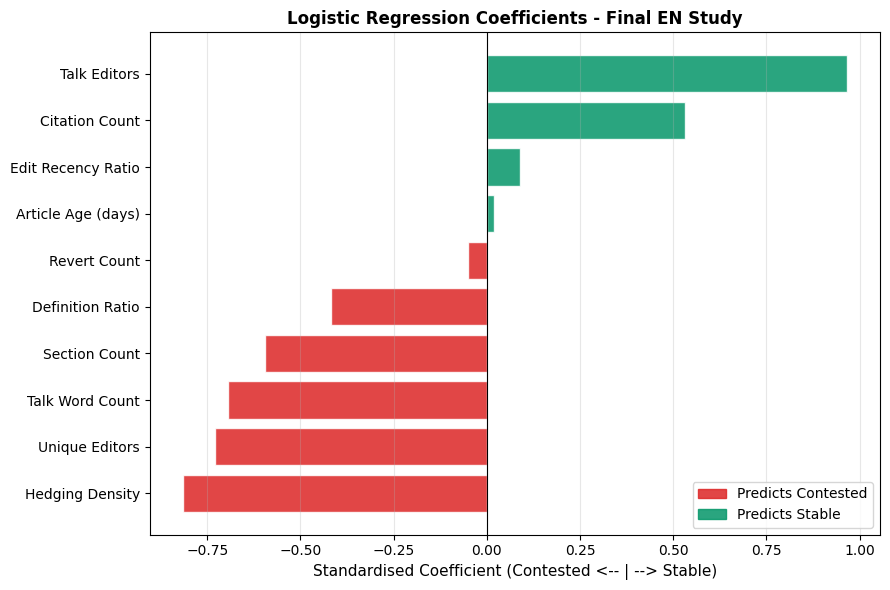

In [37]:
# Topic dummies as control variables
# Pilot Experiment 4: topic control reduced F1 by 0.098 - topic matters
df_topic = pd.get_dummies(df["topic"], prefix="topic", drop_first=True)
df_model = pd.concat([df.reset_index(drop=True),
                       df_topic.reset_index(drop=True)], axis=1)
topic_cols = list(df_topic.columns)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
m  = LogisticRegression(class_weight="balanced",
                          max_iter=1000, random_state=42)

feature_sets = {
    "Linguistic only":     ["hedging_density", "def_ratio"],
    "Structural only":     ["citation_count","section_count",
                             "unique_editors","age_days","recency_ratio"],
    "Behavioral only":     ["revert_count","talk_words","talk_editors"],
    "All features":        FEATURE_COLS,
    "All + topic control": FEATURE_COLS + topic_cols,
}

print(f"{'Feature set':<25} {'F1':>8} {'Accuracy':>10} {'vs baseline':>12}")
print("-" * 58)
results_f1 = {}

for name, feats in feature_sets.items():
    avail = [f for f in feats if f in df_model.columns]
    if len(avail) < 2: continue
    d  = df_model[avail + ["label"]].dropna()
    X  = StandardScaler().fit_transform(d[avail].values)
    y  = d["label"].values
    if len(set(y)) < 2: continue
    f1s  = cross_val_score(m, X, y, cv=cv, scoring="f1_macro")
    accs = cross_val_score(m, X, y, cv=cv, scoring="accuracy")
    base = max(y.mean(), 1-y.mean())
    results_f1[name] = f1s.mean()
    print(f"{name:<25} {f1s.mean():>8.3f} {accs.mean():>10.3f} "
          f"{accs.mean()-base:>+12.3f}")

# Coefficient chart
best_feats = [f for f in FEATURE_COLS if f in df_model.columns]
d_full = df_model[best_feats + ["label"]].dropna()
X_full = StandardScaler().fit_transform(d_full[best_feats].values)
y_full = d_full["label"].values
m.fit(X_full, y_full)

coef_df = pd.DataFrame({
    "feature":     [LABELS.get(f, f) for f in best_feats],
    "coefficient": m.coef_[0],
}).sort_values("coefficient")

fig, ax = plt.subplots(figsize=(9, 6))
colors  = ["#DC2626" if c < 0 else "#059669" for c in coef_df["coefficient"]]
ax.barh(coef_df["feature"], coef_df["coefficient"],
        color=colors, alpha=0.85, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Standardised Coefficient (Contested <-- | --> Stable)", fontsize=11)
ax.set_title("Logistic Regression Coefficients - Final EN Study",
             fontsize=12, fontweight="bold")
ax.legend(handles=[
    mpatches.Patch(color="#DC2626", alpha=0.85, label="Predicts Contested"),
    mpatches.Patch(color="#059669", alpha=0.85, label="Predicts Stable"),
], loc="lower right")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("final_coefficients_en.png", dpi=150, bbox_inches="tight")
plt.show()


## 10. Summary and Handoff Notes

In [38]:

print("=" * 70)
print("FINAL ENGLISH STUDY - SUMMARY")
print("=" * 70)

print(f"\nDataset")
print(f"  Contested : {len(contested)}/{TARGET_CONTESTED}")
print(f"  Stable    : {len(stable)}/{TARGET_STABLE_POOL}")
print(f"  Pairs     : {len(pairs)}")
print(f"  Rejected  : {len(rejected)}")
print(f"  Same topic: {same_topic}/{len(pairs)}")

print("\nTopic Distribution - Contested")
topic_summary(contested)
print("\nTopic Distribution - Stable")
topic_summary(stable)

print(f"\nMatching Quality")
print(f"  Avg distance : {avg_dist:.4f}")
print(f"  Avg age gap  : {avg_age_gap:.0f} days")
print(f"  Avg word gap : {avg_wc_gap:.1f}%")

print("\nModel Performance (5-fold CV)")
for name, f1 in results_f1.items():
    print(f"  {name:<25} F1={f1:.3f}")

sig = [r for r in wilcox_results if r["sig"]]
print(f"\nSignificant features (Wilcoxon p<0.05): {len(sig)}")
for r in sorted(sig, key=lambda x: x["p"]):
    label = LABELS.get(r["feature"], r["feature"])
    print(f"  {label:<28} p={r['p']:.4f} C>S in {r['pct_c_higher']:.0f}% of pairs")

print("\nFiles saved:")
for f in [CONTESTED_FILE, STABLE_FILE, PAIRS_FILE, FEATURES_FILE]:
    size = os.path.getsize(f) // 1024 if os.path.exists(f) else 0
    print(f"  {f} ({size}KB)")



FINAL ENGLISH STUDY - SUMMARY

Dataset
  Contested : 200/200
  Stable    : 400/400
  Pairs     : 161
  Rejected  : 39
  Same topic: 135/161

Topic Distribution - Contested
  politics_history       50 (25%)  #########################
  culture                50 (25%)  #########################
  geography              50 (25%)  #########################
  science                50 (25%)  #########################

Topic Distribution - Stable
  politics_history      100 (25%)  ##################################################
  culture               100 (25%)  ##################################################
  geography             100 (25%)  ##################################################
  science               100 (25%)  ##################################################

Matching Quality
  Avg distance : 0.0835
  Avg age gap  : 255 days
  Avg word gap : 8.9%

Model Performance (5-fold CV)
  Linguistic only           F1=0.628
  Structural only           F1=0.614
  Behavioral onl

---
## Output Files

| File | Contents |
|---|---|
| final_contested_en.json | 200 contested EN articles (50 per topic) |
| final_stable_en.json | 400 stable EN articles (100 per topic) |
| final_pairs_en.json | 200 matched pairs |
| final_features_en.csv | Feature matrix ready for analysis |
| final_good_titles_en.json | Cached Good Article titles (43K+) |
| cache_template_*.json | Template title caches (7-day expiry) |
| final_coefficients_en.png | Regression coefficient chart |


In [39]:
# ── Error Analysis ─────────────────────────────────────────────────
print("=" * 65)
print("ERROR ANALYSIS")
print("=" * 65)

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils import resample

# Rebuild model on full data to get predictions
FEAT_COLS = [f for f in FEATURE_COLS if f in df.columns]
df_m = df[FEAT_COLS + ["label", "title", "topic"]].dropna()
X    = StandardScaler().fit_transform(df_m[FEAT_COLS].values)
y    = df_m["label"].values

model_ea = LogisticRegression(class_weight="balanced",
                               max_iter=1000, random_state=42)

# ── 1. Cross-val predictions (honest) ─────────────────────────────
cv       = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_true_all, y_pred_all = [], []

for train_idx, test_idx in cv.split(X, y):
    model_ea.fit(X[train_idx], y[train_idx])
    y_true_all.extend(y[test_idx])
    y_pred_all.extend(model_ea.predict(X[test_idx]))

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# ── Confusion matrix ───────────────────────────────────────────────
cm = confusion_matrix(y_true_all, y_pred_all)
print("\nConfusion Matrix:")
print(f"                    Predicted Contested  Predicted Stable")
print(f"  Actual Contested  {cm[0][0]:>18}  {cm[0][1]:>15}")
print(f"  Actual Stable     {cm[1][0]:>18}  {cm[1][1]:>15}")

total     = len(y_true_all)
correct   = (y_true_all == y_pred_all).sum()
wrong     = total - correct
print(f"\n  Total articles : {total}")
print(f"  Correct        : {correct} ({100*correct//total}%)")
print(f"  Wrong          : {wrong} ({100*wrong//total}%)")

# False positives / negatives
fp = cm[1][0]  # stable predicted as contested
fn = cm[0][1]  # contested predicted as stable
print(f"\n  False positives: {fp} stable articles called contested")
print(f"  False negatives: {fn} contested articles called stable")

print("\nClassification Report:")
print(classification_report(y_true_all, y_pred_all,
      target_names=["Contested", "Stable"]))

# ── 2. Which articles were wrong ───────────────────────────────────
print("\n" + "=" * 65)
print("MISCLASSIFIED ARTICLES")
print("=" * 65)

# Fit on full data to get predictions for inspection
model_ea.fit(X, y)
df_m = df_m.copy()
df_m["predicted"] = model_ea.predict(X)
df_m["correct"]   = df_m["predicted"] == df_m["label"]

fp_df = df_m[(df_m.label==1) & (df_m.predicted==0)]
fn_df = df_m[(df_m.label==0) & (df_m.predicted==1)]

print(f"\nStable articles misclassified as Contested ({len(fp_df)}):")
print(f"  (These look linguistically contested but are actually stable)")
for _, row in fp_df.head(8).iterrows():
    print(f"  - {row['title'][:50]:<50} [{row['topic']}]")

print(f"\nContested articles misclassified as Stable ({len(fn_df)}):")
print(f"  (These look linguistically stable but are actually contested)")
for _, row in fn_df.head(8).iterrows():
    print(f"  - {row['title'][:50]:<50} [{row['topic']}]")

# ── 3. Per-topic performance ───────────────────────────────────────
print("\n" + "=" * 65)
print("PERFORMANCE BY TOPIC")
print("=" * 65)
print(f"\n{'Topic':<22} {'F1':>6} {'Accuracy':>10} {'n':>5}")
print("-" * 48)

for topic in ["politics_history","culture","geography","science"]:
    sub = df_m[df_m.topic == topic]
    if len(sub) < 8: continue
    X_t = StandardScaler().fit_transform(sub[FEAT_COLS].values)
    y_t = sub["label"].values
    n_splits = min(5, len(y_t)//2)
    if n_splits < 2: continue
    cv_  = StratifiedKFold(n_splits=n_splits,
                            shuffle=True, random_state=42)
    f1_  = cross_val_score(model_ea, X_t, y_t,
                            cv=cv_, scoring="f1_macro")
    acc_ = cross_val_score(model_ea, X_t, y_t,
                            cv=cv_, scoring="accuracy")
    print(f"  {topic:<20} {f1_.mean():>6.3f} {acc_.mean():>10.3f} {len(sub):>5}")

# ── 4. Bootstrap confidence intervals ─────────────────────────────
print("\n" + "=" * 65)
print("COEFFICIENT STABILITY (Bootstrap 95% CI, 500 resamples)")
print("=" * 65)

coef_boot = []
for _ in range(500):
    X_b, y_b = resample(X, y, random_state=None)
    if len(set(y_b)) < 2: continue
    m_b = LogisticRegression(class_weight="balanced",
                              max_iter=1000)
    m_b.fit(X_b, y_b)
    coef_boot.append(m_b.coef_[0])

coef_arr = np.array(coef_boot)
print(f"\n{'Feature':<25} {'Coef':>8} {'95% CI':>20}  Stable?")
print("-" * 62)
model_ea.fit(X, y)
for i, feat in enumerate(FEAT_COLS):
    lo  = np.percentile(coef_arr[:, i], 2.5)
    hi  = np.percentile(coef_arr[:, i], 97.5)
    c   = model_ea.coef_[0][i]
    # Stable if CI does not cross zero
    stable = "YES" if (lo > 0 or hi < 0) else "unstable"
    label  = LABELS.get(feat, feat)
    print(f"  {label:<23} {c:>+8.3f} [{lo:>+7.3f}, {hi:>+7.3f}]  {stable}")

print("\nYES = CI does not cross zero = reliable direction")
print("unstable = CI crosses zero = treat with caution")

# ── 5. Summary ────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("SUMMARY")
print("=" * 65)
print(f"\n  Model gets {100*correct//total}% of articles correct")
print(f"  {fp} stable articles look contested to the model")
print(f"  {fn} contested articles look stable to the model")
print(f"\n  Interpretation:")
if fn > fp:
    print("  More false negatives than false positives.")
    print("  Model is conservative - tends to call things stable.")
    print("  Some contested articles have subtle linguistic signals.")
elif fp > fn:
    print("  More false positives than false negatives.")
    print("  Model is aggressive - tends to call things contested.")
    print("  Some stable articles have noisy linguistic features.")
else:
    print("  Balanced errors - model is not systematically biased.")

ERROR ANALYSIS

Confusion Matrix:
                    Predicted Contested  Predicted Stable
  Actual Contested                 111               50
  Actual Stable                     47              122

  Total articles : 330
  Correct        : 233 (70%)
  Wrong          : 97 (29%)

  False positives: 47 stable articles called contested
  False negatives: 50 contested articles called stable

Classification Report:
              precision    recall  f1-score   support

   Contested       0.70      0.69      0.70       161
      Stable       0.71      0.72      0.72       169

    accuracy                           0.71       330
   macro avg       0.71      0.71      0.71       330
weighted avg       0.71      0.71      0.71       330


MISCLASSIFIED ARTICLES

Stable articles misclassified as Contested (40):
  (These look linguistically contested but are actually stable)
  - Bugesera invasion                                  [geography]
  - Baldwin I of Jerusalem                      